This project is a collaborative project between Colby Anderson, Salem Burtner, and Scarlett Shropshire

Colby: https://github.com/colbywanderson 
Salem: https://github.com/S-BURTNER
Scarlett: https://github.com/Scarlettshrop

In [ ]:
import glob
import pandas as pd
import numpy as np
import re
import os
import datetime
import librosa
import hashlib
import matplotlib.pyplot as plt
import IPython.display as ipd
import tensorflow as tf
import cv2
import seaborn as sns
import random
from tqdm import tqdm

from tensorflow.keras import callbacks, regularizers
from dateutil import parser
import pydub
from pydub import AudioSegment
from datetime import datetime, timedelta
from tensorflow.keras import datasets, layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.utils import resample

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


# Initial Data Exploration

### Original Dataframe created by NOAA

In [ ]:
df = pd.read_csv('https://storage.googleapis.com/noaa-passive-bioacoustic/dclde/2013/nefsc_sbnms_200903_nopp6_ch10/detections/NEFSC_SBNMS_200903_NOPP6_CH10_allbaleen_detection_log_updated-2025-07-02.csv')
df.head()

,Selection,View,Channel,Start_DateTime_ISO8601,End_DateTime_ISO8601,Low.Freq..Hz.,High.Freq..Hz.,Species,Detection_Confidence,Detection_Comments
0,1,Spectrogram 1,1,2009-03-28T00:03:08-05:00,2009-03-28T00:03:11-05:00,70.7,174.2,RIWH,Detected,NaN
1,2,Spectrogram 1,1,2009-03-28T00:03:55-05:00,2009-03-28T00:03:58-05:00,83.3,197.0,RIWH,Detected,NaN
2,3,Spectrogram 1,1,2009-03-28T00:06:38-05:00,2009-03-28T00:06:41-05:00,75.8,151.5,RIWH,Detected,NaN
3,4,Spectrogram 1,1,2009-03-28T00:07:17-05:00,2009-03-28T00:07:21-05:00,75.8,214.6,RIWH,Detected,NaN
4,5,Spectrogram 1,1,2009-03-28T00:07:30-05:00,2009-03-28T00:07:33-05:00,40.4,171.7,RIWH,Detected,NaN


Value counts of Species and Detection Confidence to determine what data needs to be cut down

In [ ]:
df.groupby('Species')[['Species','Detection_Confidence']].value_counts().reset_index()

,Species,Detection_Confidence,count
0,BLWH,Possibly_Detected,65
1,FIWH,Detected,43329
2,FIWH,Possibly_Detected,9071
3,HUWH,Detected,14869
4,HUWH,Possibly_Detected,4185
5,HUWH-MULTIPLE,Detected,1537
6,HUWH-MULTIPLE,Possibly_Detected,88
7,RIWH,Detected,5769
8,RIWH,Possibly_Detected,2897
9,SEWH,Possibly_Detected,3


Cleaned dataframe to take out uneccesary columns, instances of Possibly_Detected detection confidence, Blue Whales, Sei Whales, and instances of Mutliple Humpback Whales. We did not use these data point as we determined they were not strong enough to be used in the final model. This left about 60,000 data points.

In [ ]:
df1 = df[df['Detection_Confidence'] == 'Detected']
df2 = df1.drop('Channel', axis=1)
df3 = df2.drop('View', axis=1)
df4 = df3.drop('Detection_Comments', axis=1)
df = df4[df4['Species'] != 'HUWH-MULTIPLE']
df.head()

,Selection,Start_DateTime_ISO8601,End_DateTime_ISO8601,Low.Freq..Hz.,High.Freq..Hz.,Species,Detection_Confidence
0,1,2009-03-28T00:03:08-05:00,2009-03-28T00:03:11-05:00,70.7,174.2,RIWH,Detected
1,2,2009-03-28T00:03:55-05:00,2009-03-28T00:03:58-05:00,83.3,197.0,RIWH,Detected
2,3,2009-03-28T00:06:38-05:00,2009-03-28T00:06:41-05:00,75.8,151.5,RIWH,Detected
3,4,2009-03-28T00:07:17-05:00,2009-03-28T00:07:21-05:00,75.8,214.6,RIWH,Detected
4,5,2009-03-28T00:07:30-05:00,2009-03-28T00:07:33-05:00,40.4,171.7,RIWH,Detected


## Downsampling of the 3 remaining whale species to 1000 detections per species

Due to time, computational, and storage limitations, we decided to cut down detections to 1000 per species in order to to have managable results.

In [ ]:
# Fin Whales
df_FIWH = df[df['Species'] == 'FIWH']
df_FIWH_downsampled1 = resample(df_FIWH,random_state=42,n_samples=1000,replace=False)
df_FIWH_downsampled1.sort_values(by='Start_DateTime_ISO8601')
df_FIWH_downsampled = df_FIWH_downsampled1.sort_values(by='Start_DateTime_ISO8601')

# Humpback Whales
df_HUWH = df[df['Species'] == 'HUWH']
df_HUWH_downsampled1 = resample(df_HUWH,random_state=42,n_samples=1000,replace=False)
df_HUWH_downsampled1.sort_values(by='Start_DateTime_ISO8601')
df_HUWH_downsampled = df_HUWH_downsampled1.sort_values(by='Start_DateTime_ISO8601')

# North Atlantic Right Whales
df_RIWH = df[df['Species'] == 'RIWH']
df_RIWH_downsampled1 = resample(df_RIWH,random_state=42,n_samples=1000,replace=False)
df_RIWH_downsampled1.sort_values(by='Start_DateTime_ISO8601')
df_RIWH_downsampled = df_RIWH_downsampled1.sort_values(by='Start_DateTime_ISO8601')

# Merging Audio

Merging all 672 15-minute audio files into 7 24-hour audio files. First, the 672 files were organized into 7 folders containing 96 of the audio files

In [ ]:
# Path to folder with 96 15 minute audio files
input_folder = "Data/03_28" # manually changed the input folder for where each different day audio was held
output_file = "combined_24hr_2009_03_28.wav" # manually changed the output file for where each species audio was held

# Loading in and Sorting the files to ensure they are in the right order when combing the audio
wav_files = sorted([f for f in os.listdir(input_folder) if f.lower().endswith(".wav")])

# Create and empty audio file
combined = AudioSegment.empty()
# takes the 96 audio files and concatenates them together
for i, file_name in enumerate(wav_files, start=1):
    file_path = os.path.join(input_folder, file_name)
    segment = AudioSegment.from_wav(file_path)
    combined += segment

# Export the combined 24hr .wav audio file
combined.export(output_file, format="wav")

# Slicing the 24-hour Audio files

Once we had the 3000 detections we were going to use and the 7 24-hr audio files, we needed to cut the individual clips by referencing the time between the StartTime and EndTime columns.

In [ ]:
# function to convert the start time and end time into hms from midnight for splitting up the sounds by day
def hms_to_ms(hms_string):
    time_obj = datetime.strptime(hms_string, '%H:%M:%S').time()
    td = timedelta(hours=time_obj.hour, minutes=time_obj.minute, seconds=time_obj.second)
    total_milliseconds = int(td.total_seconds() * 1000)
    return total_milliseconds

In [ ]:
# read in the csv
df = pd.read_csv('Whale_Final.csv')

In [ ]:
# list of days to run through for times and files
days = ['2009-03-28', '2009-03-29', '2009-03-30', '2009-03-31', '2009-04-01', '2009-04-02', '2009-04-03']
days_u = ['2009_03_28', '2009_03_29', '2009_03_30', '2009_03_31', '2009_04_01', '2009_04_02', '2009_04_03']

In [ ]:
for i in range(len(days)):
    # separates the initial dataframe into separate days
    df2 = df[df['Start_DateTime_ISO8601'].str.contains(days[i])]
    species = np.array(df2['Species'])

    # read in the file based on the day
    filename = 'combined_24hr_' + days_u[i] + '.wav'
    audio = AudioSegment.from_file(filename)

    # cycle through the times and cut and save the audio based on detection time and species
    for j in range(len(df2)):
        time_start = parser.parse(df2['Start_DateTime_ISO8601'].iloc[j]).strftime("%H:%M:%S")
        time_end = parser.parse(df2['End_DateTime_ISO8601'].iloc[j]).strftime("%H:%M:%S")

        start_ms = hms_to_ms(time_start)
        end_ms = hms_to_ms(time_end)

        a = audio[start_ms:end_ms]
        a.export('test/' + species[j] + '/day_' +str(i)+ '_' + species[j] + '_' + str(j) + '.wav', format = 'wav')

# Padding and Slicing Clips

Now that we had the 3000 audio clips, we needed to either pad or slice them to be exactly 30 seconds. This was done as to properly run the CNN, all the spectrograms need to be the same size, shape, and length. We decided to do this preproccessing step with the audio.

In [ ]:
target_length = 30000  # 30 seconds in milliseconds
input_folder = "Whale_S/Whale/RIWH" # manually changed the input folder for where each species audio was held
output_folder = "New_Whale/RIWH" # manually changed the output folder for where each species audio was held

# Load in all audio files
for filename in os.listdir(input_folder):
    if filename.endswith(".wav"):
        file_path = os.path.join(input_folder, filename)

        try:
            audio = AudioSegment.from_file(file_path)
            # Determine if clips are under 30 secs
            if len(audio) < target_length:
                # Determine how much audio needs to be padded to the clip
                silence_duration = target_length - len(audio)
                # Create the padded audio and append to end of audio clip
                silence = AudioSegment.silent(duration=silence_duration)
                padded_audio = audio + silence
            else:
                padded_audio = audio[:target_length] # Slices end of audio clip if over 30 secs

            # Export the final padded audio clips to designated folder
            output_path = os.path.join(output_folder, filename)
            padded_audio.export(output_path, format="wav")

Also, for one of out models, we wanted to do a binary classification of a whale sound vs random ocean sounds. The original audio files for this were seperated similar to the original whale audio files. The following code accomplishes this by cutting the ocean sound audio files into 30 second increments.

In [ ]:
input_file = "combined_sounds.wav"
output_folder = "Ocean_sounds"
os.makedirs(output_folder, exist_ok=True)

# Load the audio file
audio = AudioSegment.from_wav(input_file)

# Clip in miliseconds to 30 seconds
clip_length = 30 * 1000

# This calculates the number of clips that will be created from the audio file
num_clips = math.ceil(len(audio) / clip_length)

# Loop through to slice audio every 30 seconds and export
for i in range(num_clips):
    start = i * clip_length
    end = min((i + 1) * clip_length, len(audio))
    clip = audio[start:end]

    clip_name = f"clip_{i+1:05d}.wav"
    clip.export(os.path.join(output_folder, clip_name), format="wav")

# Test example with Spectrogram

In [ ]:
path = ''
filename_d = path+'/content/drive/MyDrive/DSC 502 Whale Project/Whale Species padded/HUWH/day_1_HUWH_106.wav'

In [ ]:
class_names = ['FIWH', 'HUWH', 'RIWH']
class_to_index = {'FIWH' : 0, 'HUWH' : 1, 'RIWH' : 2}

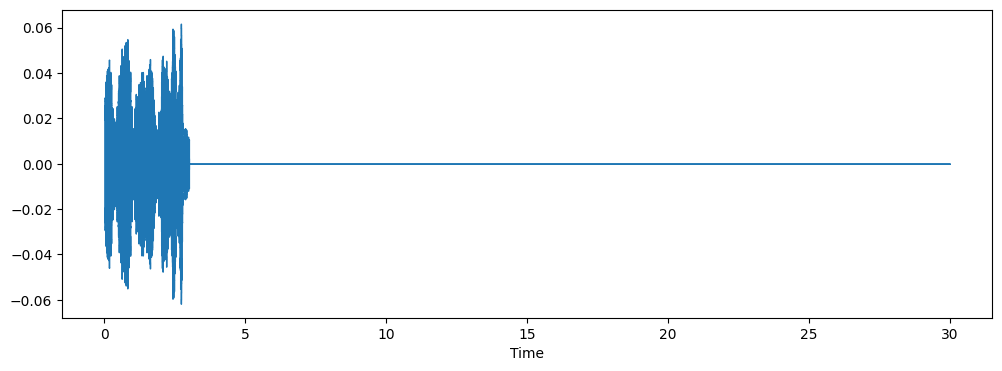

In [ ]:
plt.figure(figsize = (12, 4))
whale_sound, sample_rate = librosa.load(filename_d)
librosa.display.waveshow(whale_sound, sr=sample_rate)
ipd.Audio(filename_d)

In [ ]:
mfccs = librosa.feature.mfcc(y=whale_sound, sr=sample_rate, n_mfcc=40)

In [ ]:
whale_sound.shape

(661490,)

# Noise Spectrogram example

In [ ]:
path = ''
filename_d = path+'/content/drive/MyDrive/DSC 502 Whale Project/Ocean sounds/clip_00002.wav'

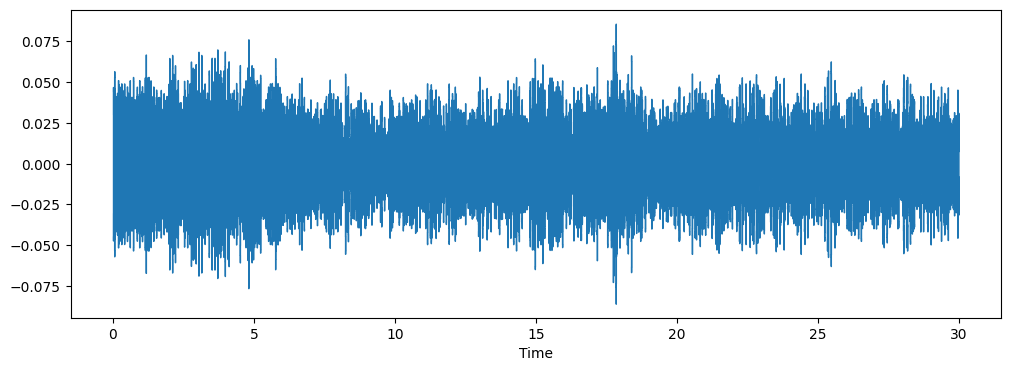

In [ ]:
plt.figure(figsize = (12, 4))
whale_sound, sample_rate = librosa.load(filename_d)
librosa.display.waveshow(whale_sound, sr=sample_rate)
ipd.Audio(filename_d)

# Model 1: Binary Classification between Whale Sounds and Ocean Noise

In [ ]:
# Initializing Variables

WHALE_ROOT = "/content/drive/MyDrive/DSC 502 Whale Project/Whale Species padded"
NOISE_ROOT = "/content/drive/MyDrive/DSC 502 Whale Project/Ocean sounds"

CACHE_DIR = "/content/drive/MyDrive/whale_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
CACHE_PATH = os.path.join(CACHE_DIR, "binary_whale_dataset.npz")


SR = 44100
AUDIO_SECONDS = 1
N_MELS = 128
TARGET_SIZE = (128, 128)
HOP_LENGTH = 512


BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-4


RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
tf.random.set_seed(RNG_SEED)

In [ ]:
# Functions for hash file as well as spectrogram converter

def md5_of_file(path):
    """Return MD5 hash of a file so we can detect duplicates."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

def audio2mel(file_path):
    """Load audio → pad/trim → mel spectrogram → normalize → resize."""
    y, _ = librosa.load(file_path, sr=SR)

    target_len = SR * AUDIO_SECONDS
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalize per spectrogram
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-9)

    # Resize to 128×128
    mel_resized = cv2.resize(
        mel_db, (TARGET_SIZE[1], TARGET_SIZE[0]), interpolation=cv2.INTER_AREA
    )

    return mel_resized.astype(np.float32)

def drop_duplicate_paths(file_list):
    """Remove exact duplicate *audio files* using MD5 hashing."""
    seen = {}
    unique = []
    for p in file_list:
        try:
            h = md5_of_file(p)
            if h not in seen:
                seen[h] = p
                unique.append(p)
        except:
            pass
    return unique

In [ ]:
# Collecting files for conversion

def collect_files(whale_root, noise_root):
    whale_files = []

    # species subfolders (HUWH, FIWH, RIWH)
    for entry in os.listdir(whale_root):
        folder = os.path.join(whale_root, entry)
        if os.path.isdir(folder):
            whale_files += glob.glob(folder + "/*.wav")
            whale_files += glob.glob(folder + "/*.WAV")

    noise_files = glob.glob(os.path.join(noise_root, "*.wav")) \
                + glob.glob(os.path.join(noise_root, "*.WAV"))

    return sorted(list(set(whale_files))), sorted(list(set(noise_files)))

whale_files, noise_files = collect_files(WHALE_ROOT, NOISE_ROOT)

print("Whale files:", len(whale_files))
print("Noise files:", len(noise_files))

Whale files: 3000
Noise files: 3000


In [ ]:
# Splitting files for training and validation data

all_files = whale_files + noise_files
all_labels = [1]*len(whale_files) + [0]*len(noise_files)

combined = list(zip(all_files, all_labels))
random.shuffle(combined)

all_files, all_labels = zip(*combined)
all_files = list(all_files)
all_labels = list(all_labels)

train_files, val_files, y_train_files, y_val_files = train_test_split(
    all_files, all_labels,
    test_size=0.2,
    random_state=RNG_SEED,
    stratify=all_labels
)

print("Train files:", len(train_files))
print("Val files:", len(val_files))

Train files: 4800
Val files: 1200


In [ ]:
# Spectrogram conversion

use_cache = False

if os.path.exists(CACHE_PATH):
    data = np.load(CACHE_PATH, allow_pickle=True)
    cached_train = data["train_files"].tolist()
    cached_val   = data["val_files"].tolist()

    if set(cached_train) == set(train_files) and set(cached_val) == set(val_files):
        print("Using cached spectrograms.")
        X_train = data["X_train"]
        X_val   = data["X_val"]
        y_train = data["y_train"]
        y_val   = data["y_val"]
        use_cache = True
    else:
        print("Cache exists but split changed → regenerating.")

if not use_cache:
    print("Generating spectrograms (one time only)…")

    X_train = [audio2mel(f) for f in tqdm(train_files)]
    X_val   = [audio2mel(f) for f in tqdm(val_files)]

    X_train = np.array(X_train)[..., np.newaxis]
    X_val   = np.array(X_val)[..., np.newaxis]
    y_train = np.array(y_train_files)
    y_val   = np.array(y_val_files)

    # save cache
    np.savez_compressed(
        CACHE_PATH,
        X_train=X_train, X_val=X_val,
        y_train=y_train, y_val=y_val,
        train_files=np.array(train_files),
        val_files=np.array(val_files)
    )
    print("Saved cache →", CACHE_PATH)

Using cached spectrograms.


In [ ]:
# Model

input_shape = X_train.shape[1:]

model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,889 (398.00 KB)

 Trainable params: 101,441 (396.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Training model

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[reduce_lr, early_stop]
)

Epoch 1/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9162 - loss: 0.3038 - val_accuracy: 0.5000 - val_loss: 0.6950 - learning_rate: 1.0000e-04
Epoch 2/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9968 - loss: 0.0407 - val_accuracy: 0.5000 - val_loss: 0.6920 - learning_rate: 1.0000e-04
Epoch 3/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9989 - loss: 0.0171 - val_accuracy: 0.5000 - val_loss: 0.6993 - learning_rate: 1.0000e-04
Epoch 4/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9989 - loss: 0.0122 - val_accuracy: 0.5000 - val_loss: 0.5971 - learning_rate: 1.0000e-04
Epoch 5/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9993 - loss: 0.0062 - val_accuracy: 1.0000 - val_loss: 0.0352 - learning_rate: 1.0000e-04
Epoch 6/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9998 - loss: 0.0042 - val_accuracy: 1.0000 - val_loss: 0.0022 - learning_rate: 1.0000e-04
Epoch 7/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - ac

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


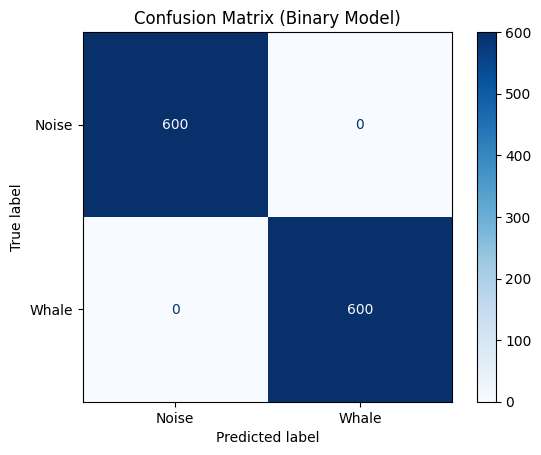

In [ ]:
# Confusion Matrix
y_prob = model.predict(X_val)

y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)

class_names = ['Noise', 'Whale']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Binary Model)")
plt.show()

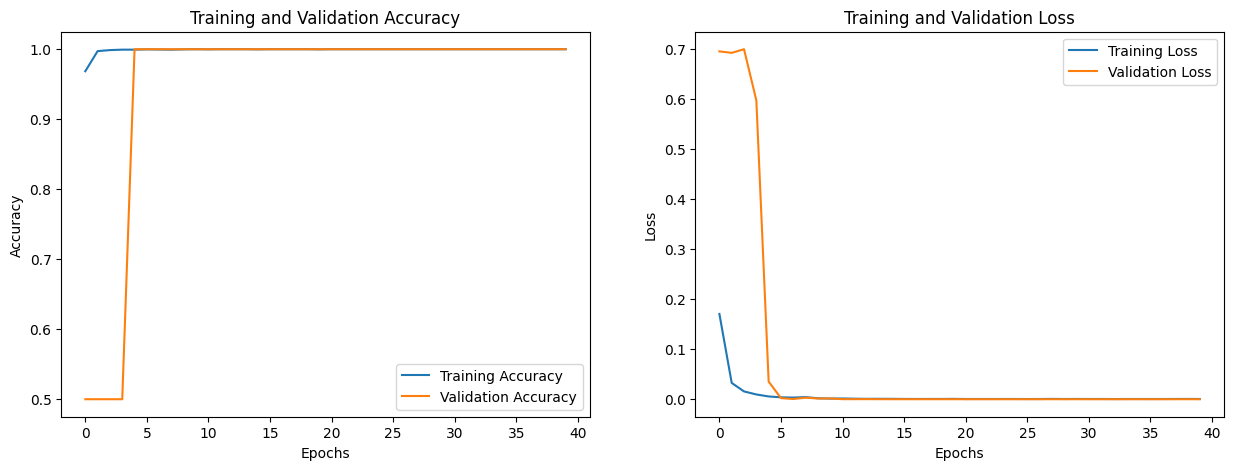

In [ ]:
# Validation and Training Curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.savefig('training_history.png')
plt.show()

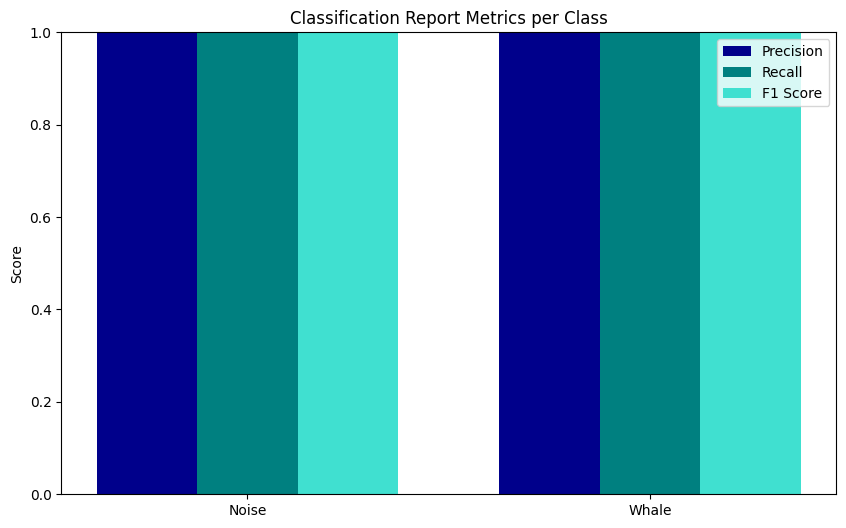

In [ ]:
# Classification Report

report = classification_report(y_val, y_pred, output_dict=True)

classes = ['0', '1']

pretty_names = {
    '0': 'Noise',
    '1': 'Whale'
}

precision = [report[c]['precision'] for c in classes]
recall    = [report[c]['recall'] for c in classes]
f1        = [report[c]['f1-score'] for c in classes]

plt.figure(figsize=(10,6))

x = np.arange(len(classes))
width = 0.25

plt.bar(x - width, precision, width, label='Precision', color = 'darkblue')
plt.bar(x, recall, width, label='Recall', color = 'teal')
plt.bar(x + width, f1, width, label='F1 Score', color = 'turquoise')

plt.xticks(x, [pretty_names[c] for c in classes])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Classification Report Metrics per Class")
plt.legend()
plt.show()

# Model 2: Multi-Class Classification between Whale Species

In [ ]:
# Collecting Files
def collect_files(root, class_names):
    species_files = {}

    for cname in class_names:
        folder = os.path.join(root, cname)
        files = [os.path.join(folder, f)
                 for f in os.listdir(folder)
                 if f.endswith(".wav")]

        species_files[cname] = files

    return species_files

In [ ]:
DATASET_ROOT = "/content/drive/MyDrive/DSC 502 Whale Project/Whale Species padded"
class_names = ['FIWH', 'HUWH', 'RIWH']

In [ ]:
# Collecting Individual
species_files = collect_files(DATASET_ROOT, class_names)

In [ ]:
# Spectrogram Conversion Function with Simplifications

def audio2mel(file, n_mels=256, hop_length = 256):
    sound, sample_rate = librosa.load(file, res_type='soxr_hq')
    k = 44100
    if len(sound) < k:
        sound_new = np.zeros(k)
        sound_new[:len(sound)] = sound
    else:
        sound_new = sound[:k]

    # Compute mel spectrogram
    mel = librosa.feature.melspectrogram(y=sound_new, sr=sample_rate, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Resize to square for the CNN
    mel_resized = cv2.resize(mel_db, (128, 128))
    return mel_resized

In [ ]:
# Function to load species into an array and help convert to spectrograms
def load_species(files):
    # compute shape once
    sample_spec = audio2mel(files[0])
    H, W = sample_spec.shape

    data = np.empty((len(files), H, W, 1), dtype=np.float32)

    for i, f in enumerate(files):
        mel = audio2mel(f)

        # normalize
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)

        # add channel
        data[i, :, :, 0] = mel

    return data

In [ ]:
# Separating into arrays for train_test_split
all_data = []
all_labels = []

for cname in class_names:
    files = species_files[cname]

    print("Loading:", cname, "with", len(files), "files")

    X = load_species(files)  # spectrograms
    y = np.full((len(X),), class_to_index[cname])  # labels

    all_data.append(X)
    all_labels.append(y)

Loading: FIWH with 1000 files
Loading: HUWH with 1000 files
Loading: RIWH with 1000 files


In [ ]:
X = np.concatenate(all_data, axis=0)
y = np.concatenate(all_labels, axis=0)

In [ ]:
# Splitting into validationa and training data
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    shuffle=True,
    random_state=42
)

In [ ]:
# Normalizing Data
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / (std + 1e-6)
X_val = (X_val - mean) / (std + 1e-6)

In [ ]:
# Model Building and Fitting

input_shape = (128, 128, 1)

model = models.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same', kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax'),
])


callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[callbacks]
)

Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.4441 - loss: 1.0597 - val_accuracy: 0.3333 - val_loss: 1.4775 - learning_rate: 0.0010
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4802 - loss: 1.0192 - val_accuracy: 0.3333 - val_loss: 2.1291 - learning_rate: 0.0010
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5116 - loss: 0.9959 - val_accuracy: 0.3517 - val_loss: 2.5085 - learning_rate: 0.0010
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5328 - loss: 0.9598 - val_accuracy: 0.3517 - val_loss: 2.3311 - learning_rate: 0.0010
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5664 - loss: 0.9122 - val_accuracy: 0.3517 - val_loss: 2.3451 - learning_rate: 0.0010
Epoch 6/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5742 - loss: 0.9074 - val_accuracy: 0.3517 - val_loss: 2.3294 - learning_rate: 0.0010
Epoch 7/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6167 - loss: 0.8581 - val_acc

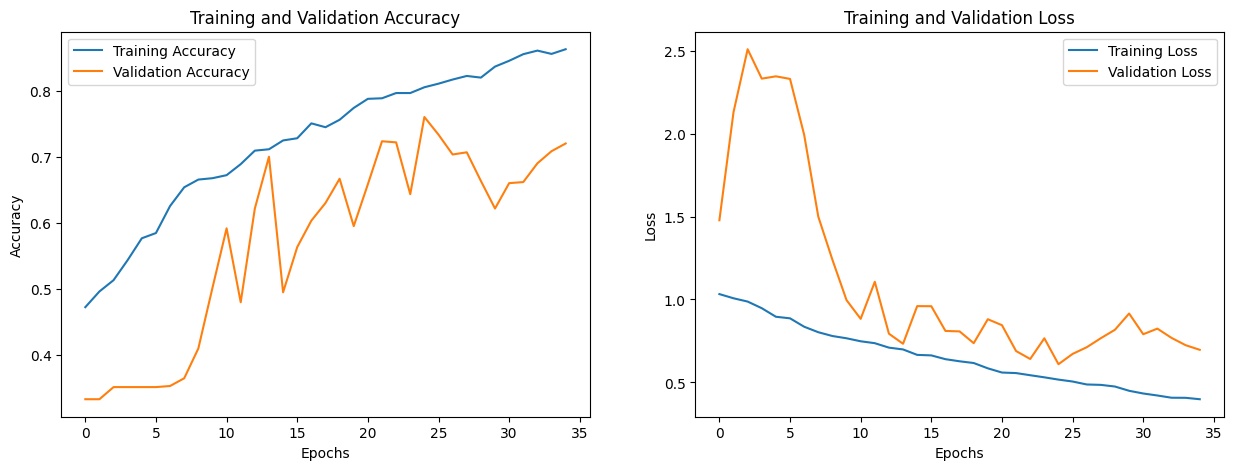

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.savefig('training_history.png')
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


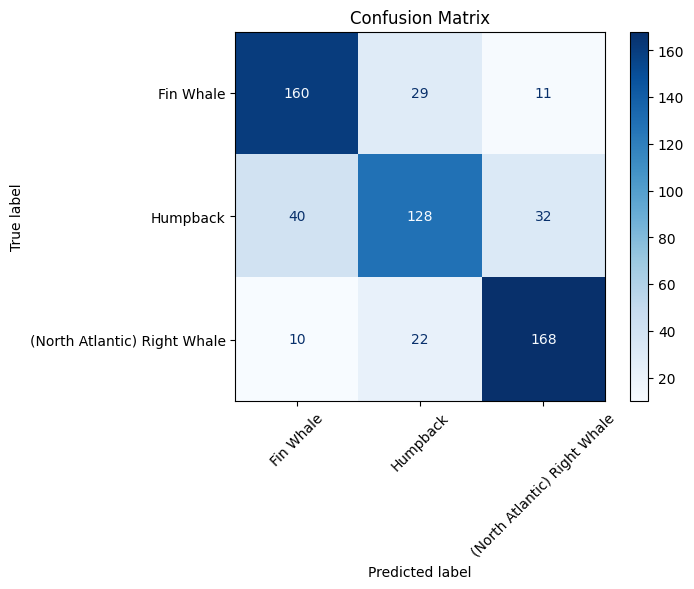

In [ ]:
cm = confusion_matrix(y_val, np.argmax(model.predict(X_val), axis=-1))
class_names = ['Fin Whale', 'Humpback', '(North Atlantic) Right Whale']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


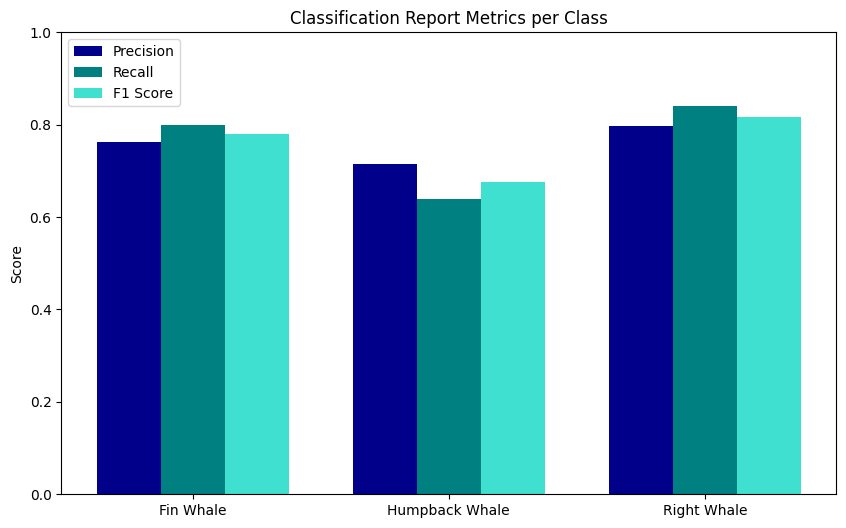

In [ ]:
report = classification_report(y_val, np.argmax(model.predict(X_val), axis=-1), output_dict=True)
classes = ['0', '1', '2']

pretty_names = {
    '0': 'Fin Whale',
    '1': 'Humpback Whale',
    '2': 'Right Whale'
}

precision = [report[c]['precision'] for c in classes]
recall    = [report[c]['recall'] for c in classes]
f1        = [report[c]['f1-score'] for c in classes]

plt.figure(figsize=(10,6))

x = np.arange(len(classes))
width = 0.25

plt.bar(x - width, precision, width, label='Precision', color = 'darkblue')
plt.bar(x, recall, width, label='Recall', color = 'teal')
plt.bar(x + width, f1, width, label='F1 Score', color = 'turquoise')

plt.xticks(x, [pretty_names[c] for c in classes])
plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Classification Report Metrics per Class")
plt.legend()
plt.show()
